# Telecom Customer Churn Prediction

## Exploratory Data Analysis

### 1) Problem Statement

This project aims to understand the factors that influence customer churn
in a telecommunications company. We will analyze variables such as
contract renewal, data plan, data usage, customer service calls,
monthly charges, and roaming minutes to identify patterns associated
with customer churn.

### 2) Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 3) Loading Data from MongoDB

In [5]:
import sys
sys.path.append("..")

from src.components.data_ingestions import fetch_data_from_mongodb

df = fetch_data_from_mongodb()

In [6]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,118,0,0,0.00,0,223.4,98,57.0,11.03,6.3
1,0,73,1,0,0.00,1,224.4,90,52.0,7.98,13.0
2,0,98,1,0,0.30,3,126.3,102,39.0,8.34,9.4
3,0,116,1,1,3.13,2,268.6,83,92.3,8.91,11.6
4,1,155,1,0,0.00,0,203.4,100,51.0,9.55,8.9


In [7]:
df.shape

(3333, 11)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [10]:
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


### 4) Data Checks

#### 4.1) Missing Values

In [11]:
df.isnull().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

#### 4.2) Duplicate Rows

In [12]:
df.duplicated().sum()

np.int64(0)

#### 4.3) Target Value

In [13]:
df['Churn'].value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

#### 4.4) Data Distribution

In [14]:
df.columns

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='str')

In [16]:
numerical_columns = [
    'AccountWeeks',
    'DataUsage',
    'CustServCalls',
    'DayMins',
    'DayCalls',
    'MonthlyCharge',
    'OverageFee',
    'RoamMins'
]

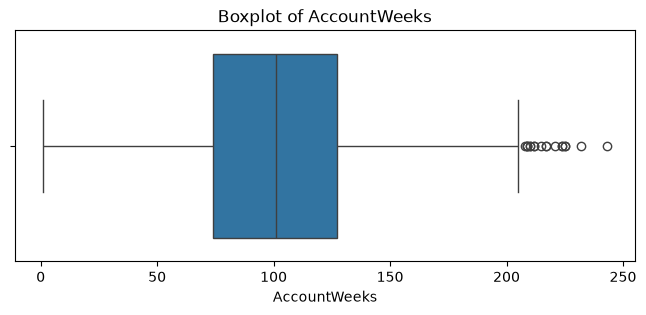

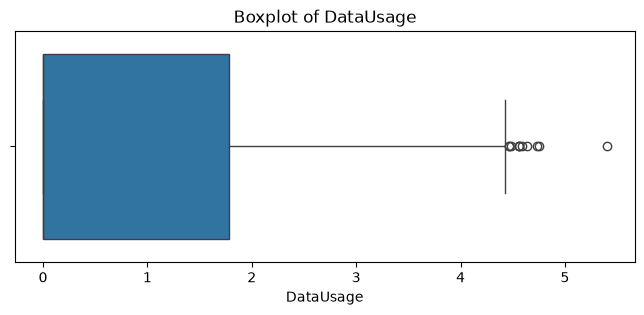

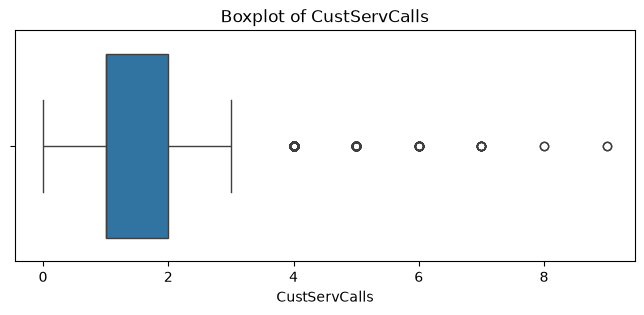

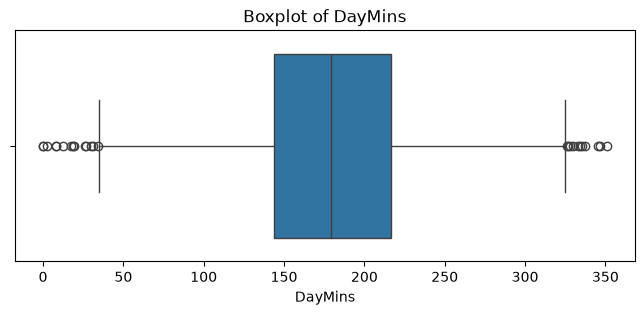

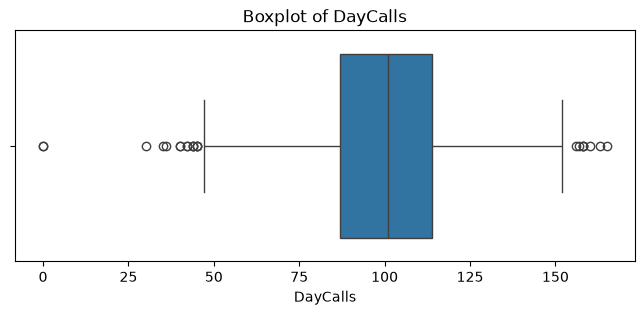

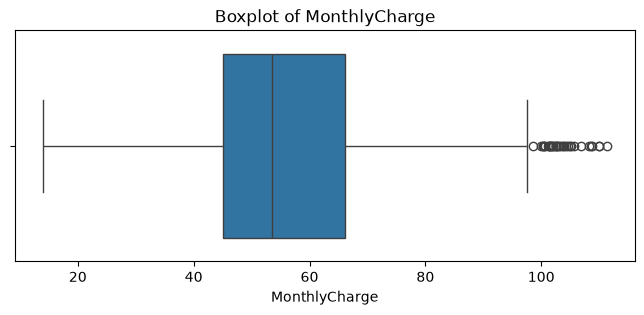

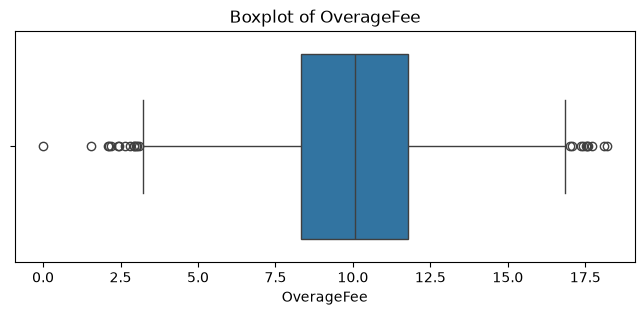

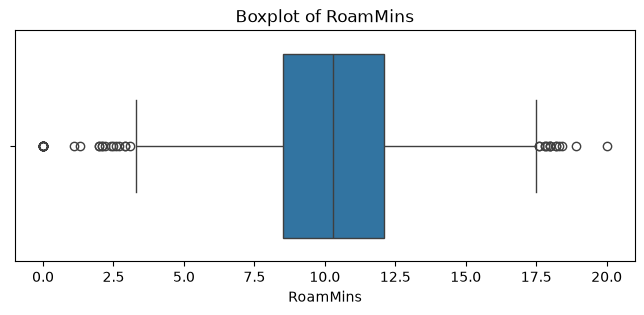

In [17]:
for column in numerical_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()